Import Libraries

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Scenario 1: The Missing Measurement

Counts: {'0': 526, '1': 498}


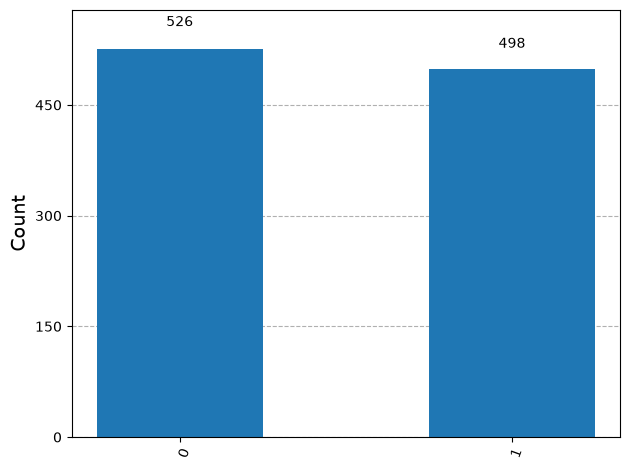

In [2]:
qc = QuantumCircuit(2, 1)
qc.h(0)
qc.cx(0, 1)
qc.measure(0, 0)

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

The Fix

Counts: {'00': 522, '11': 502}


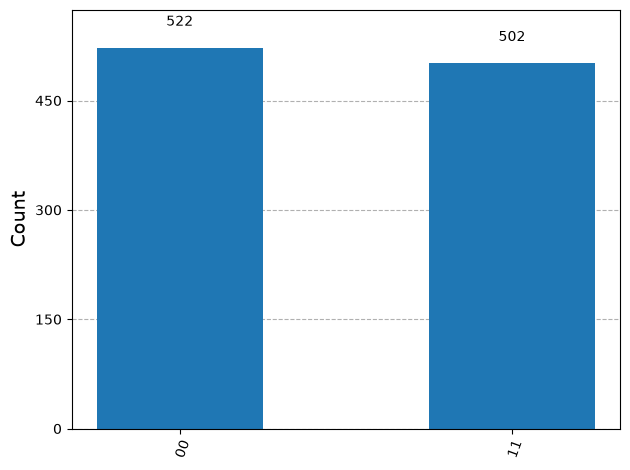

In [3]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

Scenario 2: Wrong Qubit Index

Counts: {'10': 1024}


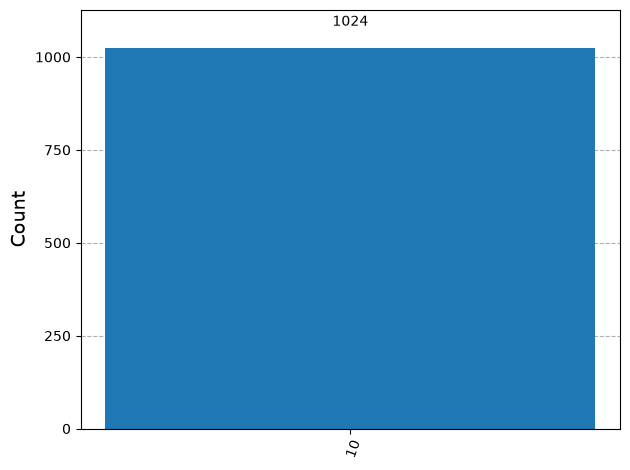

In [4]:
qc = QuantumCircuit(2, 2)
qc.x(1)  # Oops — meant to flip qubit 0
qc.measure([0, 1], [0, 1])

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

The Fix

Counts: {'01': 1024}


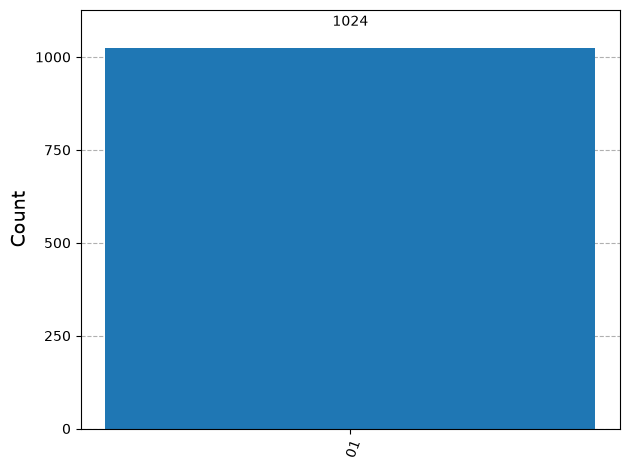

In [5]:
qc = QuantumCircuit(2, 2)
qc.x(0)  # Correct index
qc.measure([0, 1], [0, 1])

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

Scenario 3: Superposition Gone Wrong

Counts: {'00': 486, '10': 538}


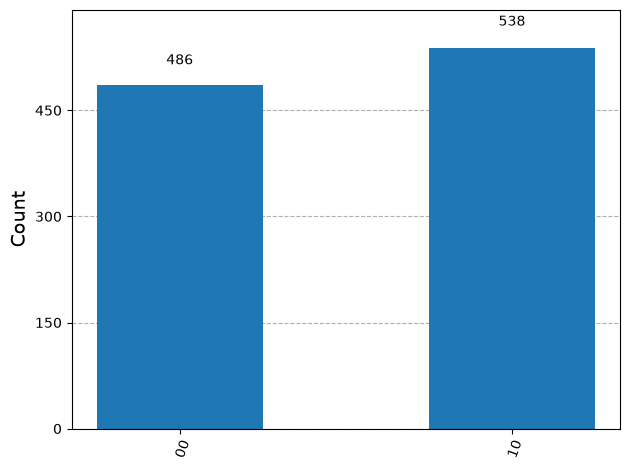

In [6]:
qc = QuantumCircuit(2, 2)
qc.h(1)  # Meant to apply to qubit 0
qc.measure([0, 1], [0, 1])

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

The Fix

Counts: {'01': 513, '00': 511}


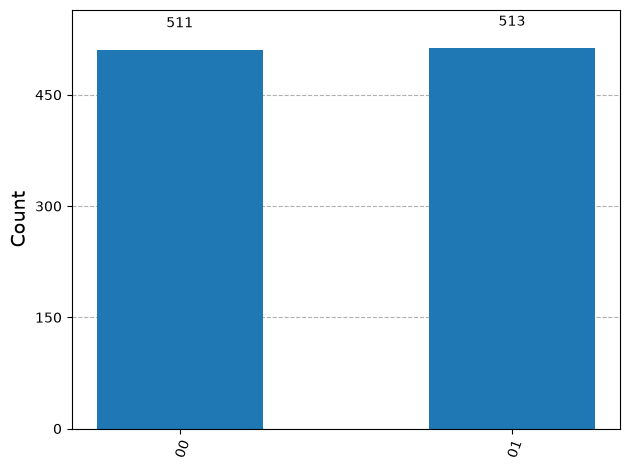

In [7]:
qc = QuantumCircuit(2, 2)
qc.h(0)  # Correct qubit
qc.measure([0, 1], [0, 1])

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

Visualizing the Circuit

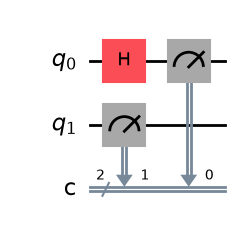

In [8]:
qc.draw('mpl')